In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load Dataset
df = pd.read_csv("marketing_campaign.csv", sep='\t')

print("Dataset Shape:", df.shape)


Dataset Shape: (2240, 29)


In [3]:
print("\nMissing Values:")
print(df.isnull().sum())

# Median Imputation
df['Income'].fillna(df['Income'].median(), inplace=True)

print("\nMissing Values After Treatment:")
print(df.isnull().sum())


Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing Values After Treatment:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Custo

/tmp/ipykernel_4926/1682670934.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)


In [4]:
df['Age'] = 2026 - df['Year_Birth']

df['Total_Children'] = (
    df['Kidhome'] +
    df['Teenhome']
)

df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

df['Total_Purchases'] = (
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

df['Income_Per_Child'] = (
    df['Income'] /
    (df['Total_Children'] + 1)
)

In [5]:
numeric_cols = [
    'Income',
    'Age',
    'Total_Spending',
    'Total_Purchases'
]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(
        df[col] < lower,
        lower,
        df[col]
    )

    df[col] = np.where(
        df[col] > upper,
        upper,
        df[col]
    )

print("Outliers Treated Successfully")

Outliers Treated Successfully


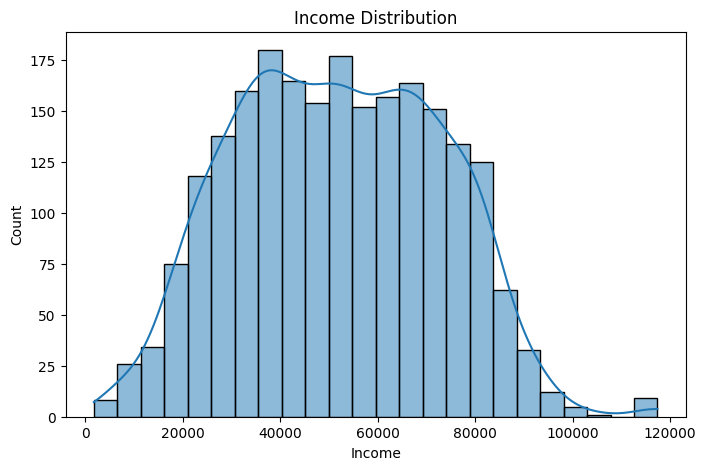

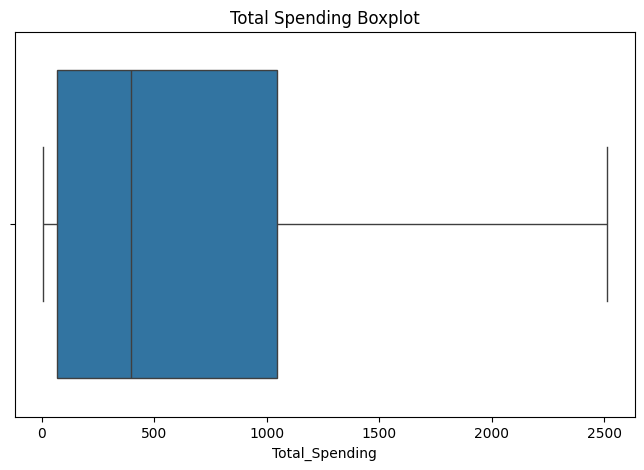

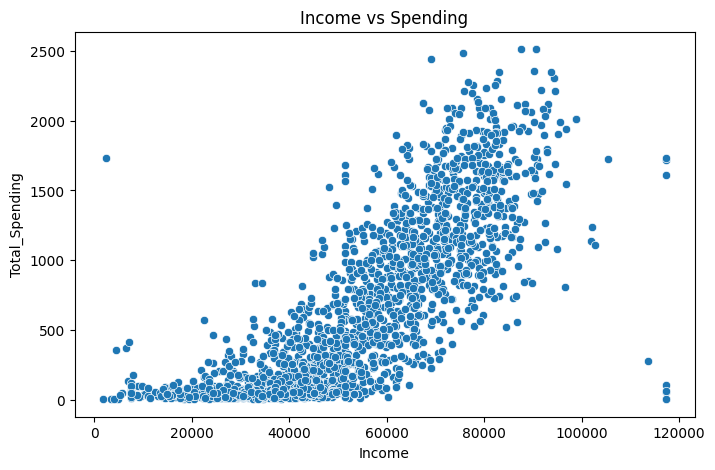

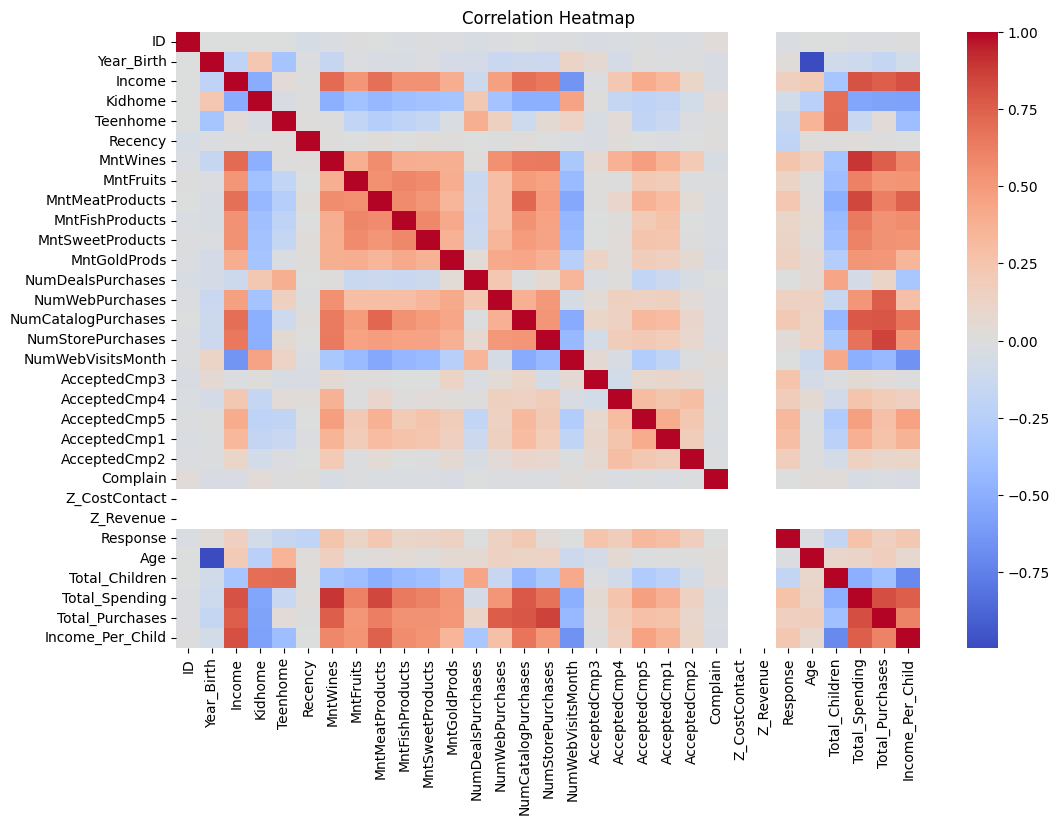

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df['Total_Spending'])
plt.title("Total Spending Boxplot")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Income',
    y='Total_Spending',
    data=df
)
plt.title("Income vs Spending")
plt.show()

# Correlation Heatmap

plt.figure(figsize=(12,8))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [7]:
print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ====================================
# STEP 6 : Save Clean Dataset
# ====================================

df.to_csv(
    "cleaned_marketing_campaign.csv",
    index=False
)

print(
    "\nCleaned Dataset Saved Successfully!"
)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    22